In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

n_samples = 2000
n_features = 1000
n_true_factors = 200 

true_factors =  rng.normal(0,1, size=(n_samples, n_true_factors))
mixing_weights = rng.normal(0,1, size=(n_true_factors, n_features))
X = true_factors @ mixing_weights + rng.normal(0, 0.5, size=(n_samples, n_features))

true_coefficients = rng.normal(0,1, size=(n_true_factors,))
y = true_factors @ true_coefficients + rng.normal(0, 0.5, size=(n_samples,))

print(f"X shape: {X.shape} (1000 columns, but only {n_true_factors} are truly independent)")

X shape: (2000, 1000) (1000 columns, but only 200 are truly independent)


In [2]:
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

baseline_model = LinearRegression().fit(X_train_scaled, y_train)
r2_baseline = r2_score(y_test, baseline_model.predict(X_test_scaled))

print(f"LinearRegression on all {X.shape[1]} raw features - > test R^2 = {r2_baseline:.3f}")

LinearRegression on all 1000 raw features - > test R^2 = 0.995


In [4]:
pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

for n_comp in[50,100,150,200,250,300]:
    print(f"First {n_comp:4d} components explain {cumulative_variance[n_comp-1]:.1%} of variance in the data.")

First   50 components explain 45.4% of variance in the data.
First  100 components explain 73.2% of variance in the data.
First  150 components explain 90.4% of variance in the data.
First  200 components explain 99.9% of variance in the data.
First  250 components explain 99.9% of variance in the data.
First  300 components explain 99.9% of variance in the data.


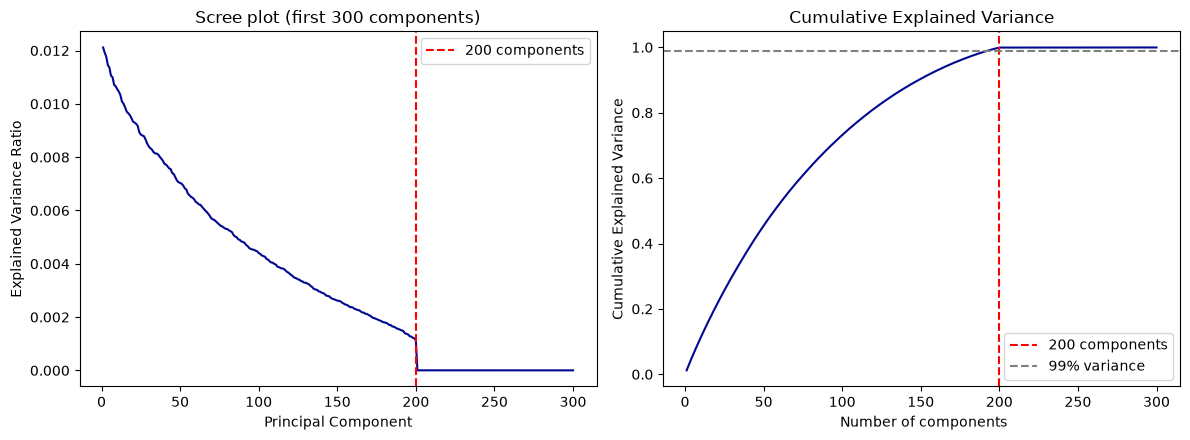

In [7]:
fig, axes = plt.subplots(1 , 2,figsize=(12,4.5))

axes[0].plot(range(1,301), pca_full.explained_variance_ratio_[:300], color="#020890")
axes[0].axvline(200, color="red", linestyle="--", label="200 components")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].set_title("Scree plot (first 300 components)")
axes[0].legend()

axes[1].plot(range(1,301), cumulative_variance[:300], color="#020890")
axes[1].axvline(200, color="red", linestyle="--", label="200 components")
axes[1].axhline(0.99, color="gray", linestyle="--", label="99% variance")
axes[1].set_xlabel(" Number of components")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].set_title("Cumulative Explained Variance")
axes[1].legend()

plt.tight_layout()
plt.show()


In [8]:
results = {}
for n_comp in [50,100,150,200,250,300]:
    pca = PCA(n_components=n_comp, random_state=42)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    model = LinearRegression().fit(X_train_pca, y_train)
    r2 = r2_score(y_test, model.predict(X_test_pca))
    results[n_comp] = r2
    print(f"PCA with {n_comp:4d} components -> test R^2 = {r2:.3f}")
    
print(f"\nFor comparison, all  {X.shape[1]} raw features -> test R^2 = {r2_baseline:.3f}")

PCA with   50 components -> test R^2 = 0.322
PCA with  100 components -> test R^2 = 0.487
PCA with  150 components -> test R^2 = 0.714
PCA with  200 components -> test R^2 = 0.998
PCA with  250 components -> test R^2 = 0.998
PCA with  300 components -> test R^2 = 0.998

For comparison, all  1000 raw features -> test R^2 = 0.995
